In [26]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.datasets import make_classification
from sklearn.datasets import make_regression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score

from sklearn.svm import SVC



import warnings
warnings.filterwarnings('ignore')

21] Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy

In [12]:
# Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the base estimator (Decision Tree Classifier)
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging Classifier with the Decision Tree as the base estimator
bagging_classifier = BaggingClassifier(base_estimator=dt_classifier, n_estimators=50, random_state=42)

# Train the Bagging Classifier
bagging_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bagging_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print the model accuracy
print(f"Bagging Classifier Accuracy: {accuracy * 100:.2f}%")


Bagging Classifier Accuracy: 87.00%


22] Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)

In [13]:
# Create a sample regression dataset
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the base estimator (Decision Tree Regressor)
dt_regressor = DecisionTreeRegressor(random_state=42)

# Initialize the Bagging Regressor with the Decision Tree as the base estimator
bagging_regressor = BaggingRegressor(base_estimator=dt_regressor, n_estimators=50, random_state=42)

# Train the Bagging Regressor
bagging_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bagging_regressor.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Print the Mean Squared Error
print(f"Bagging Regressor Mean Squared Error: {mse:.2f}")

Bagging Regressor Mean Squared Error: 7848.96


23]Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores

In [14]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest Classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print(f"Random Forest Classifier Accuracy: {accuracy * 100:.2f}%")

# Get the feature importance scores
feature_importances = rf_classifier.feature_importances_

# Print the feature importance scores
for feature, importance in zip(data.feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

Random Forest Classifier Accuracy: 97.08%
mean radius: 0.0323
mean texture: 0.0111
mean perimeter: 0.0601
mean area: 0.0538
mean smoothness: 0.0062
mean compactness: 0.0092
mean concavity: 0.0806
mean concave points: 0.1419
mean symmetry: 0.0033
mean fractal dimension: 0.0031
radius error: 0.0164
texture error: 0.0032
perimeter error: 0.0118
area error: 0.0295
smoothness error: 0.0059
compactness error: 0.0046
concavity error: 0.0058
concave points error: 0.0034
symmetry error: 0.0040
fractal dimension error: 0.0071
worst radius: 0.0780
worst texture: 0.0188
worst perimeter: 0.0743
worst area: 0.1182
worst smoothness: 0.0118
worst compactness: 0.0175
worst concavity: 0.0411
worst concave points: 0.1271
worst symmetry: 0.0129
worst fractal dimension: 0.0069


24]Train a Random Forest Regressor and compare its performance with a single Decision Tree

In [15]:
# Create a sample regression dataset
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42)

# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Decision Tree Regressor
dt_regressor.fit(X_train, y_train)

# Train the Random Forest Regressor
rf_regressor.fit(X_train, y_train)

# Make predictions using both models
y_pred_dt = dt_regressor.predict(X_test)
y_pred_rf = rf_regressor.predict(X_test)

# Calculate Mean Squared Error for both models
mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Print MSE for both models
print(f"Decision Tree Regressor Mean Squared Error: {mse_dt:.2f}")
print(f"Random Forest Regressor Mean Squared Error: {mse_rf:.2f}")

Decision Tree Regressor Mean Squared Error: 23700.97
Random Forest Regressor Mean Squared Error: 7367.32


25] Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier

In [16]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier with oob_score enabled
rf_classifier = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)

# Train the Random Forest Classifier
rf_classifier.fit(X_train, y_train)

# Get the Out-of-Bag (OOB) score
oob_score = rf_classifier.oob_score_

# Print the OOB score
print(f"Out-of-Bag Score: {oob_score:.4f}")

Out-of-Bag Score: 0.9548


26] Train a Bagging Classifier using SVM as a base estimator and print accuracy

In [19]:
from sklearn.datasets import load_iris

# Load the Iris dataset (a common classification dataset)
data = load_iris()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the SVM base estimator (Support Vector Classifier)
svm_classifier = SVC(random_state=42)

# Initialize the Bagging Classifier with the SVM as the base estimator
bagging_classifier = BaggingClassifier(base_estimator=svm_classifier, n_estimators=50, random_state=42)

# Train the Bagging Classifier
bagging_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bagging_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print(f"Bagging Classifier (SVM base) Accuracy: {accuracy * 100:.2f}%")

Bagging Classifier (SVM base) Accuracy: 100.00%


27] Train a Random Forest Classifier with different numbers of trees and compare accuracy

Accuracy with 10 trees: 100.00%
Accuracy with 50 trees: 100.00%
Accuracy with 100 trees: 100.00%
Accuracy with 200 trees: 100.00%
Accuracy with 500 trees: 100.00%


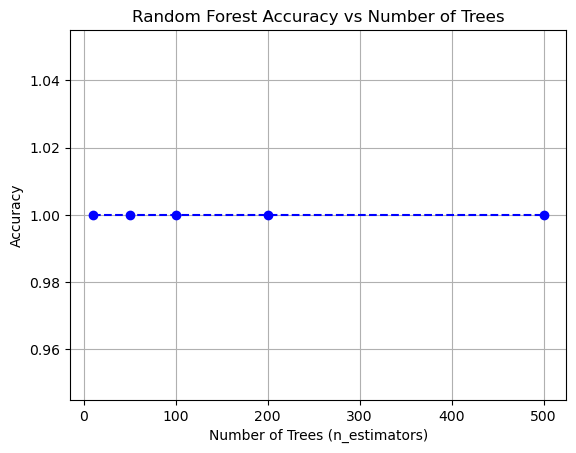

In [20]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# List of different numbers of trees (n_estimators) to test
n_estimators_list = [10, 50, 100, 200, 500]
accuracies = []

# Train Random Forest Classifier with different numbers of trees
for n_estimators in n_estimators_list:
    # Initialize the Random Forest Classifier with n_estimators
    rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    
    # Train the model
    rf_classifier.fit(X_train, y_train)
    
    # Make predictions
    y_pred = rf_classifier.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"Accuracy with {n_estimators} trees: {accuracy * 100:.2f}%")

# Plotting the accuracy for different numbers of trees
plt.plot(n_estimators_list, accuracies, marker='o', color='b', linestyle='--')
plt.title('Random Forest Accuracy vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

28] Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score

In [21]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Logistic Regression base estimator
log_regressor = LogisticRegression(solver='liblinear', random_state=42)

# Initialize the Bagging Classifier with Logistic Regression as the base estimator
bagging_classifier = BaggingClassifier(base_estimator=log_regressor, n_estimators=50, random_state=42)

# Train the Bagging Classifier
bagging_classifier.fit(X_train, y_train)

# Predict probabilities for the test set (for AUC calculation, we need probabilities)
y_pred_prob = bagging_classifier.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)

# Print the AUC score
print(f"Bagging Classifier (Logistic Regression base) AUC score: {auc_score:.4f}")


Bagging Classifier (Logistic Regression base) AUC score: 0.9984


29]Train a Random Forest Regressor and analyze feature importance scores

MedInc: 0.5260
HouseAge: 0.0547
AveRooms: 0.0472
AveBedrms: 0.0300
Population: 0.0317
AveOccup: 0.1382
Latitude: 0.0861
Longitude: 0.0861


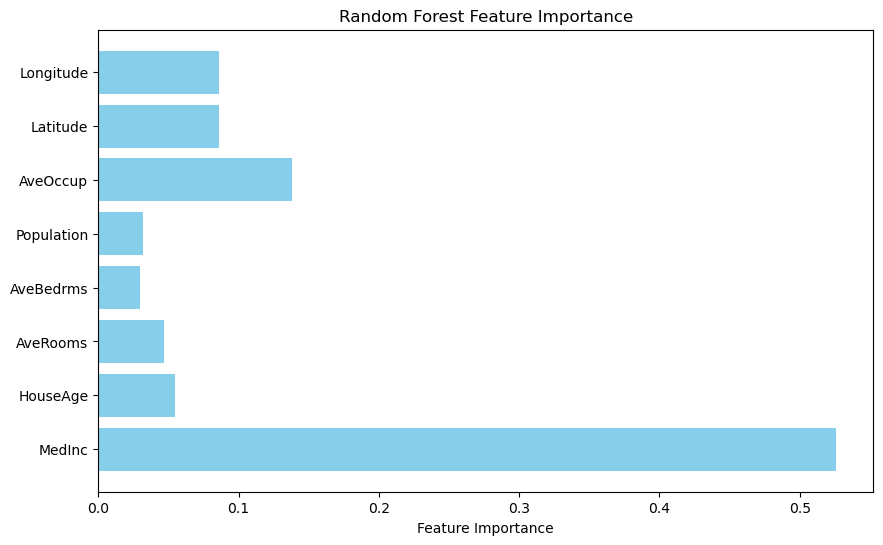

In [22]:
from sklearn.datasets import fetch_california_housing  

# Load the California Housing dataset (you can use any other dataset like Boston Housing too)
data = fetch_california_housing()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Random Forest Regressor
rf_regressor.fit(X_train, y_train)

# Get the feature importance scores
feature_importances = rf_regressor.feature_importances_

# Print the feature importance scores
for feature, importance in zip(data.feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

# Optionally, plot the feature importance scores
plt.figure(figsize=(10, 6))
plt.barh(data.feature_names, feature_importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


30] Train an ensemble model using both Bagging and Random Forest and compare accuracy

In [23]:
# Load the Iris dataset (a classification dataset)
data = load_iris()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier (Base Estimator for Bagging)
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging Classifier with Decision Trees as base estimators
bagging_classifier = BaggingClassifier(base_estimator=dt_classifier, n_estimators=50, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42)

# Train the Bagging Classifier
bagging_classifier.fit(X_train, y_train)

# Train the Random Forest Classifier
rf_classifier.fit(X_train, y_train)

# Make predictions using both classifiers
y_pred_bagging = bagging_classifier.predict(X_test)
y_pred_rf = rf_classifier.predict(X_test)

# Calculate the accuracy for both models
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Print the accuracy scores for both models
print(f"Bagging Classifier Accuracy: {accuracy_bagging * 100:.2f}%")
print(f"Random Forest Classifier Accuracy: {accuracy_rf * 100:.2f}%")

Bagging Classifier Accuracy: 100.00%
Random Forest Classifier Accuracy: 100.00%


31]Train a Random Forest Classifier and tune hyperparameters using GridSearchCV

In [24]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Step 2: Load your dataset
# Example: Using sklearn's breast cancer dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X = data.data  # Features
y = data.target  # Target labels

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Train a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Step 5: Define the hyperparameters for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Maximum depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples to split an internal node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required to be at a leaf node
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider for the best split
    'bootstrap': [True, False]  # Whether bootstrap samples are used when building trees
}

# Step 6: Use GridSearchCV to tune the hyperparameters
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Step 7: Get the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

# Step 8: Evaluate the model on the test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Step 9: Print the classification report
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best score: 0.9597784810126582
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        63
           1       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



32]Train a Bagging Regressor with different numbers of base estimators and compare performance

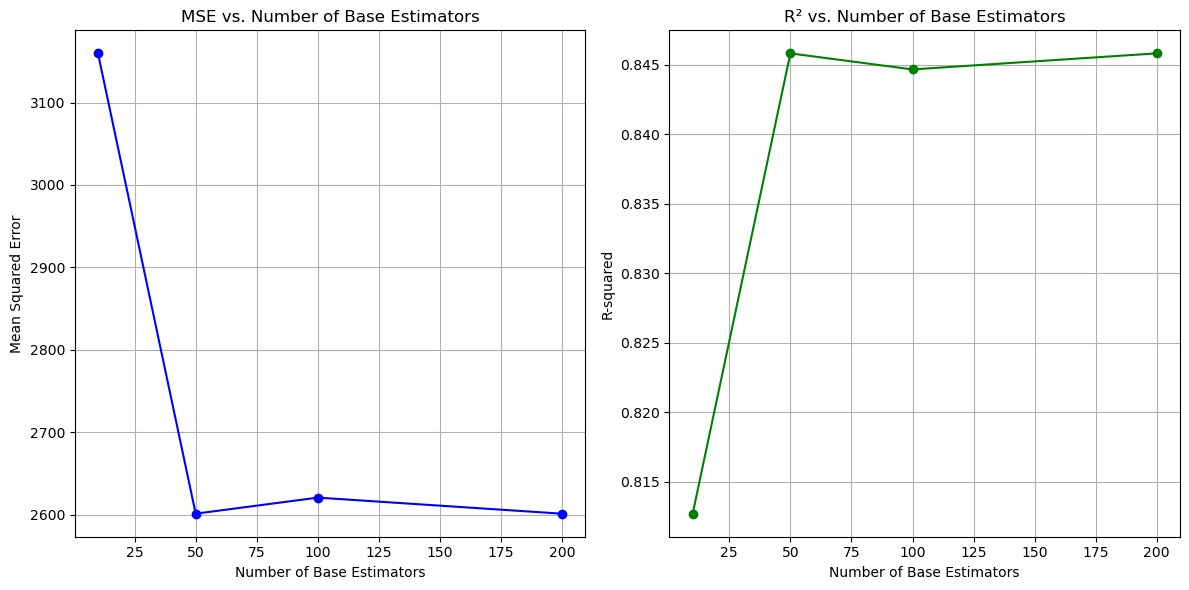

Base Estimators: 10 | MSE: 3159.7242 | R²: 0.8127
Base Estimators: 50 | MSE: 2601.0756 | R²: 0.8458
Base Estimators: 100 | MSE: 2620.5504 | R²: 0.8447
Base Estimators: 200 | MSE: 2601.0318 | R²: 0.8458


In [27]:
# 1. Generate a synthetic dataset (or load your own dataset)
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)

# 2. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the range of base estimators (e.g., 10, 50, 100, 200)
n_estimators_list = [10, 50, 100, 200]

# 4. Store the performance metrics
mse_scores = []
r2_scores = []

# 5. Loop over the different numbers of estimators
for n_estimators in n_estimators_list:
    # 6. Initialize Bagging Regressor with DecisionTreeRegressor as the base estimator
    bagging_model = BaggingRegressor(base_estimator=DecisionTreeRegressor(), n_estimators=n_estimators, random_state=42)
    
    # 7. Train the model
    bagging_model.fit(X_train, y_train)
    
    # 8. Make predictions
    y_pred = bagging_model.predict(X_test)
    
    # 9. Evaluate the model performance (using Mean Squared Error and R-squared)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 10. Append the results
    mse_scores.append(mse)
    r2_scores.append(r2)

# 11. Plot the results for comparison
plt.figure(figsize=(12, 6))

# Plot MSE
plt.subplot(1, 2, 1)
plt.plot(n_estimators_list, mse_scores, marker='o', color='blue', label='MSE')
plt.title('MSE vs. Number of Base Estimators')
plt.xlabel('Number of Base Estimators')
plt.ylabel('Mean Squared Error')
plt.grid(True)

# Plot R²
plt.subplot(1, 2, 2)
plt.plot(n_estimators_list, r2_scores, marker='o', color='green', label='R²')
plt.title('R² vs. Number of Base Estimators')
plt.xlabel('Number of Base Estimators')
plt.ylabel('R-squared')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

# Print out the performance for each configuration
for n_estimators, mse, r2 in zip(n_estimators_list, mse_scores, r2_scores):
    print(f"Base Estimators: {n_estimators} | MSE: {mse:.4f} | R²: {r2:.4f}")


33] Train a Random Forest Classifier and analyze misclassified samples

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Misclassified Samples:


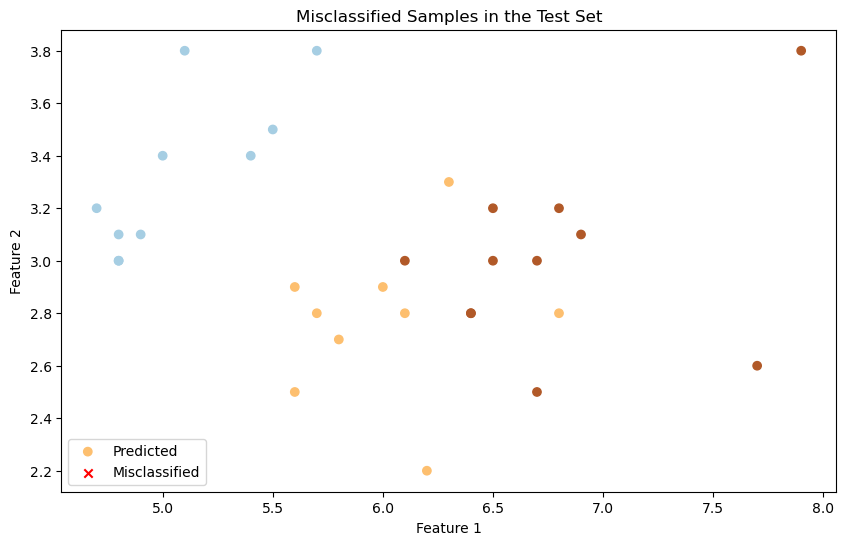

In [29]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load a dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# 5. Evaluate model performance
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Identify misclassified samples
misclassified_idx = np.where(y_pred != y_test)[0]
misclassified_samples = X_test[misclassified_idx]
misclassified_true_labels = y_test[misclassified_idx]
misclassified_pred_labels = y_pred[misclassified_idx]

# 7. Print out misclassified samples
print("\nMisclassified Samples:")
for idx, (true_label, pred_label, sample) in enumerate(zip(misclassified_true_labels, misclassified_pred_labels, misclassified_samples)):
    print(f"Sample {misclassified_idx[idx]} | True label: {true_label} | Predicted label: {pred_label} | Sample: {sample}")

# 8. Visualize the misclassified samples (optional)
plt.figure(figsize=(10, 6))

# Plot misclassified points in 2D space (using first two features for simplicity)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap=plt.cm.Paired, marker='o', label='Predicted')
plt.scatter(misclassified_samples[:, 0], misclassified_samples[:, 1], color='red', edgecolor='black', marker='x', label='Misclassified')
plt.title('Misclassified Samples in the Test Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


34] Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier

Decision Tree Classifier Performance:
Accuracy: 1.0000
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Bagging Classifier Performance:
Accuracy: 1.0000
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00     

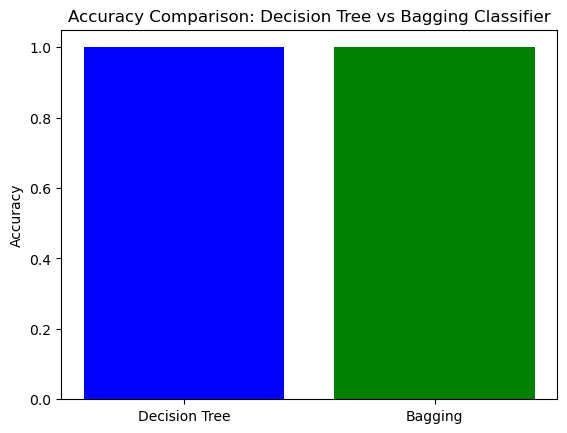

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load a dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 4. Train a Bagging Classifier with Decision Tree as the base estimator
bagging_classifier = BaggingClassifier(base_estimator=DecisionTreeClassifier(),
                                      n_estimators=50, random_state=42)
bagging_classifier.fit(X_train, y_train)

# 5. Make predictions using both models
dt_pred = dt_classifier.predict(X_test)
bagging_pred = bagging_classifier.predict(X_test)

# 6. Evaluate the performance of both models
dt_accuracy = accuracy_score(y_test, dt_pred)
bagging_accuracy = accuracy_score(y_test, bagging_pred)

# Confusion Matrix and Classification Report
dt_conf_matrix = confusion_matrix(y_test, dt_pred)
bagging_conf_matrix = confusion_matrix(y_test, bagging_pred)

dt_class_report = classification_report(y_test, dt_pred)
bagging_class_report = classification_report(y_test, bagging_pred)

# 7. Print results
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {dt_accuracy:.4f}")
print("Confusion Matrix:\n", dt_conf_matrix)
print("Classification Report:\n", dt_class_report)

print("\nBagging Classifier Performance:")
print(f"Accuracy: {bagging_accuracy:.4f}")
print("Confusion Matrix:\n", bagging_conf_matrix)
print("Classification Report:\n", bagging_class_report)

# 8. Visualizing the comparison of accuracies
plt.bar(['Decision Tree', 'Bagging'], [dt_accuracy, bagging_accuracy], color=['blue', 'green'])
plt.title('Accuracy Comparison: Decision Tree vs Bagging Classifier')
plt.ylabel('Accuracy')
plt.show()


35] Train a Random Forest Classifier and visualize the confusion matrix

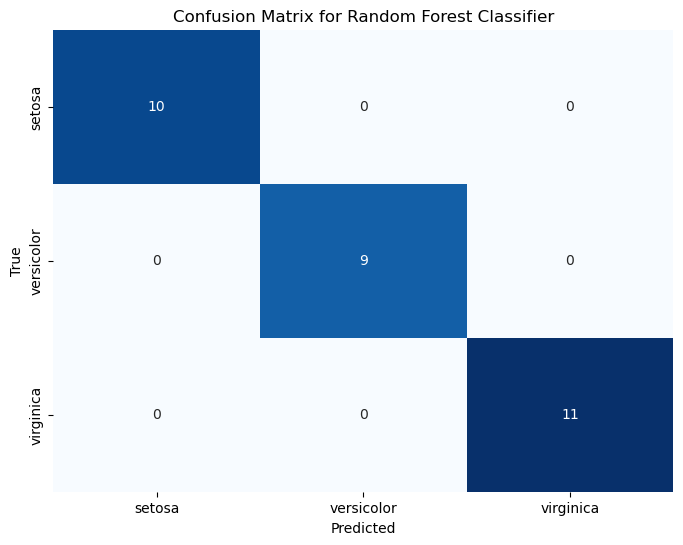

In [33]:
import seaborn as sns
# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# 5. Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# 6. Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

36] Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy

Decision Tree Accuracy: 1.0000
SVM Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000
Stacking Classifier Accuracy: 1.0000


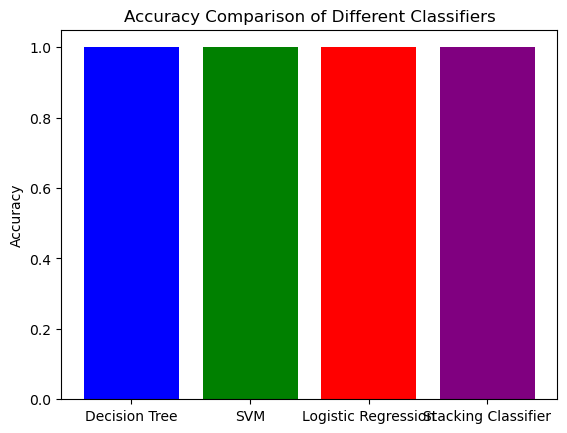

In [34]:
from sklearn.ensemble import StackingClassifier
from sklearn.datasets import load_iris


# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the base classifiers
dt_classifier = DecisionTreeClassifier(random_state=42)
svm_classifier = SVC(random_state=42)
lr_classifier = LogisticRegression(random_state=42)

# 4. Create the Stacking Classifier
stacking_classifier = StackingClassifier(estimators=[
    ('dt', dt_classifier),
    ('svm', svm_classifier),
    ('lr', lr_classifier)
], final_estimator=LogisticRegression())

# 5. Train each model and make predictions
# Train Decision Tree
dt_classifier.fit(X_train, y_train)
dt_pred = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# Train SVM
svm_classifier.fit(X_train, y_train)
svm_pred = svm_classifier.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

# Train Logistic Regression
lr_classifier.fit(X_train, y_train)
lr_pred = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Train Stacking Classifier
stacking_classifier.fit(X_train, y_train)
stacking_pred = stacking_classifier.predict(X_test)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

# 6. Print out the accuracies
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Stacking Classifier Accuracy: {stacking_accuracy:.4f}")

# 7. Visualize the comparison of accuracies
plt.bar(['Decision Tree', 'SVM', 'Logistic Regression', 'Stacking Classifier'],
        [dt_accuracy, svm_accuracy, lr_accuracy, stacking_accuracy],
        color=['blue', 'green', 'red', 'purple'])
plt.title('Accuracy Comparison of Different Classifiers')
plt.ylabel('Accuracy')
plt.show()


37]Train a Random Forest Classifier and print the top 5 most important features

In [35]:
from sklearn.datasets import load_iris

# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 4. Get feature importances
feature_importances = rf_classifier.feature_importances_

# 5. Create a DataFrame to view features and their importance
features = data.feature_names
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort the features by importance (descending order)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the top 5 most important features
print("Top 5 Most Important Features:")
print(importance_df.head(5))


Top 5 Most Important Features:
             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


38] Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score

In [36]:
from sklearn.datasets import load_iris

# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 4. Get feature importances
feature_importances = rf_classifier.feature_importances_

# 5. Create a DataFrame to view features and their importance
features = data.feature_names
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort the features by importance (descending order)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the top 5 most important features
print("Top 5 Most Important Features:")
print(importance_df.head(5))


Top 5 Most Important Features:
             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


39]Train a Random Forest Classifier and analyze the effect of max_depth on accuracy

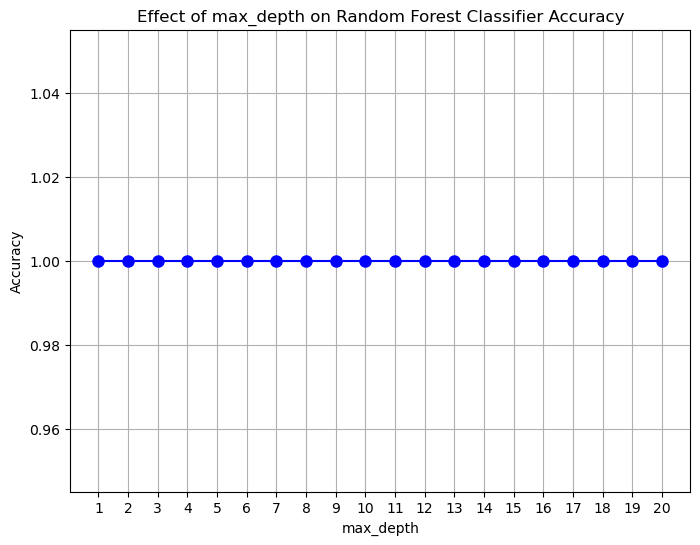

max_depth: 1, Accuracy: 1.0000
max_depth: 2, Accuracy: 1.0000
max_depth: 3, Accuracy: 1.0000
max_depth: 4, Accuracy: 1.0000
max_depth: 5, Accuracy: 1.0000
max_depth: 6, Accuracy: 1.0000
max_depth: 7, Accuracy: 1.0000
max_depth: 8, Accuracy: 1.0000
max_depth: 9, Accuracy: 1.0000
max_depth: 10, Accuracy: 1.0000
max_depth: 11, Accuracy: 1.0000
max_depth: 12, Accuracy: 1.0000
max_depth: 13, Accuracy: 1.0000
max_depth: 14, Accuracy: 1.0000
max_depth: 15, Accuracy: 1.0000
max_depth: 16, Accuracy: 1.0000
max_depth: 17, Accuracy: 1.0000
max_depth: 18, Accuracy: 1.0000
max_depth: 19, Accuracy: 1.0000
max_depth: 20, Accuracy: 1.0000


In [37]:
# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize variables to store results
max_depths = np.arange(1, 21)  # Test max_depth values from 1 to 20
accuracies = []

# 4. Train Random Forest Classifier for different max_depth values
for max_depth in max_depths:
    rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=max_depth, random_state=42)
    rf_classifier.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_pred = rf_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# 5. Plot the effect of max_depth on accuracy
plt.figure(figsize=(8, 6))
plt.plot(max_depths, accuracies, marker='o', color='b', linestyle='-', markersize=8)
plt.title('Effect of max_depth on Random Forest Classifier Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(max_depths)
plt.grid(True)
plt.show()

# 6. Print the results
for depth, acc in zip(max_depths, accuracies):
    print(f"max_depth: {depth}, Accuracy: {acc:.4f}")

40] Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare 
performance

Decision Tree Regressor - MSE: 0.2573, R²: 0.8036
KNeighbors Regressor - MSE: 1.0763, R²: 0.1787


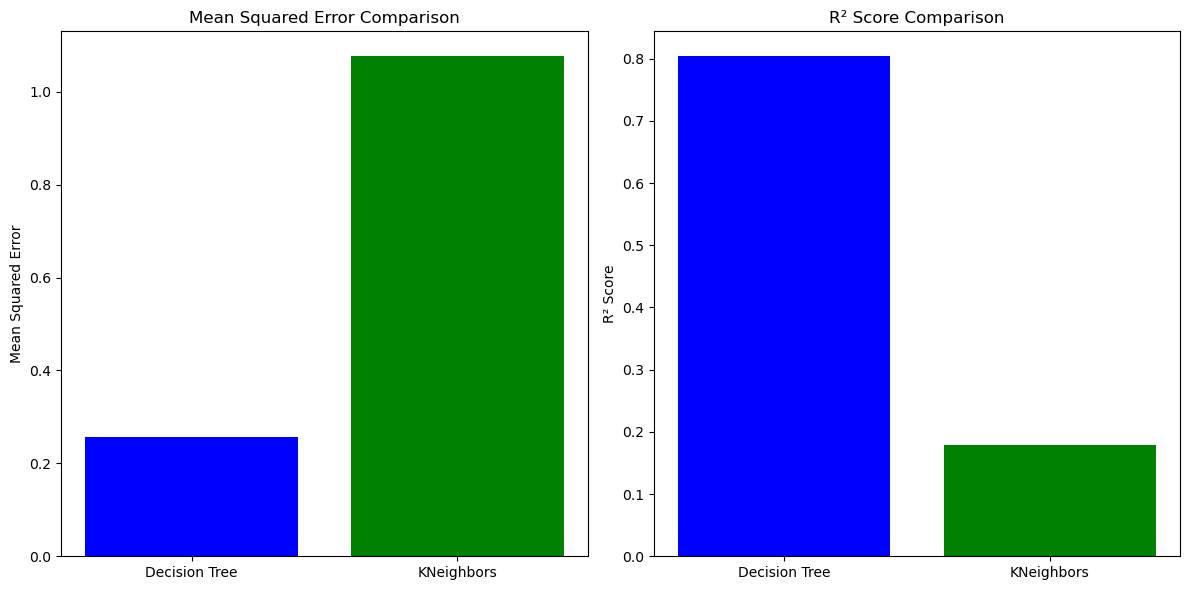

In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing

# 1. Load the dataset (California Housing dataset in this example)
data = fetch_california_housing()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize Bagging Regressors with different base estimators
# Bagging with Decision Tree as base estimator
dt_regressor = BaggingRegressor(base_estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)

# Bagging with KNeighbors as base estimator
knn_regressor = BaggingRegressor(base_estimator=KNeighborsRegressor(), n_estimators=50, random_state=42)

# 4. Train the models
dt_regressor.fit(X_train, y_train)
knn_regressor.fit(X_train, y_train)

# 5. Make predictions
y_pred_dt = dt_regressor.predict(X_test)
y_pred_knn = knn_regressor.predict(X_test)

# 6. Evaluate performance using Mean Squared Error (MSE) and R^2 score
mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_knn = mean_squared_error(y_test, y_pred_knn)

r2_dt = r2_score(y_test, y_pred_dt)
r2_knn = r2_score(y_test, y_pred_knn)

# 7. Print the results
print(f"Decision Tree Regressor - MSE: {mse_dt:.4f}, R²: {r2_dt:.4f}")
print(f"KNeighbors Regressor - MSE: {mse_knn:.4f}, R²: {r2_knn:.4f}")

# 8. Compare the performance visually
models = ['Decision Tree', 'KNeighbors']
mse_values = [mse_dt, mse_knn]
r2_values = [r2_dt, r2_knn]

# Plot MSE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(models, mse_values, color=['blue', 'green'])
plt.title('Mean Squared Error Comparison')
plt.ylabel('Mean Squared Error')

# Plot R² Score
plt.subplot(1, 2, 2)
plt.bar(models, r2_values, color=['blue', 'green'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()


41]Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score

ROC-AUC Score: 1.0000


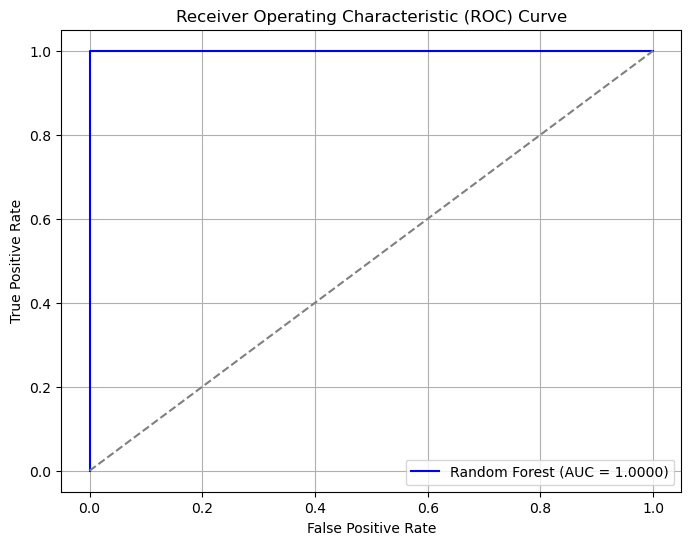

In [40]:
from sklearn.datasets import load_iris
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# Convert the problem to a binary classification (for ROC-AUC calculation)
# We'll just use classes 0 and 1 for simplicity
y_binary = (y == 0).astype(int)

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = rf_classifier.predict(X_test)
y_pred_prob = rf_classifier.predict_proba(X_test)[:, 1]  # Probability for the positive class

# 5. Compute the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 6. Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# 7. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


 42]Train a Bagging Classifier and evaluate its performance using cross-validation

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_iris


# Step 1: Load a dataset
data = load_iris()
X = data.data
y = data.target

# Step 2: Initialize the BaggingClassifier
# We use a DecisionTreeClassifier as the base estimator
bagging_clf = BaggingClassifier(base_estimator=DecisionTreeClassifier(),
                               n_estimators=50, random_state=42)

# Step 3: Evaluate using cross-validation (e.g., 5-fold cross-validation)
cv_scores = cross_val_score(bagging_clf, X, y, cv=5)

# Output the cross-validation scores and mean score
print("Cross-validation scores: ", cv_scores)
print("Mean CV score: ", np.mean(cv_scores))


Cross-validation scores:  [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV score:  0.9666666666666668


43] Train a Random Forest Classifier and plot the Precision-Recall curve

Average Precision Score: 1.0000


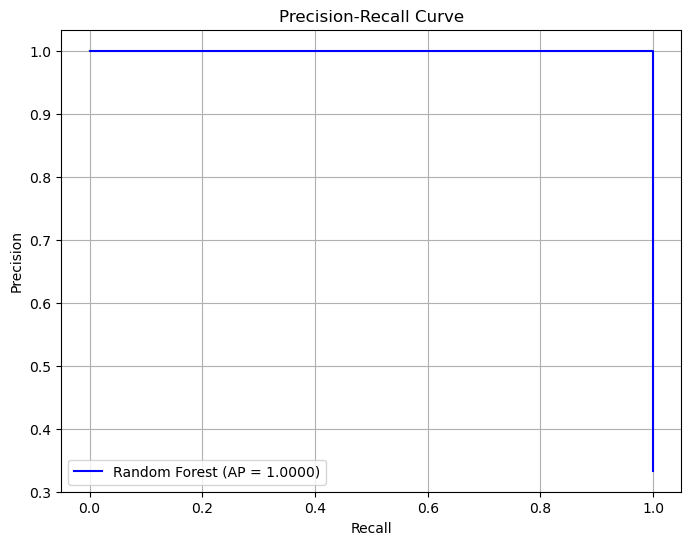

In [41]:
from sklearn.datasets import load_iris
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 1. Load the dataset (Iris dataset in this example)
data = load_iris()
X = data.data
y = data.target

# Convert the problem to a binary classification (class 0 vs class 1)
y_binary = (y == 0).astype(int)

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred_prob = rf_classifier.predict_proba(X_test)[:, 1]  # Probability for the positive class

# 5. Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# 6. Compute the Average Precision Score (AUC of Precision-Recall curve)
average_precision = average_precision_score(y_test, y_pred_prob)
print(f"Average Precision Score: {average_precision:.4f}")

# 7. Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Random Forest (AP = {average_precision:.4f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


44] Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Step 11: Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Initialize the base learners
rf = RandomForestClassifier(n_estimators=50, random_state=42)
lr = LogisticRegression(max_iter=200, random_state=42)

# Step 4: Initialize the Stacking Classifier
# Here, we use Logistic Regression as the final estimator (meta-model)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf), ('lr', lr)], 
    final_estimator=LogisticRegression()
)

# Step 5: Train the individual classifiers
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Step 6: Train the Stacking Classifier
stacking_clf.fit(X_train, y_train)

# Step 7: Evaluate the performance of individual classifiers and the stacked classifier
rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
stacking_pred = stacking_clf.predict(X_test)

# Step 8: Calculate the accuracy of each model
rf_accuracy = accuracy_score(y_test, rf_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

# Print the results
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Stacking Classifier Accuracy: {stacking_accuracy:.4f}")


Random Forest Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000
Stacking Classifier Accuracy: 1.0000


45] Train a Bagging Regressor with different levels of bootstrap samples and compare performance

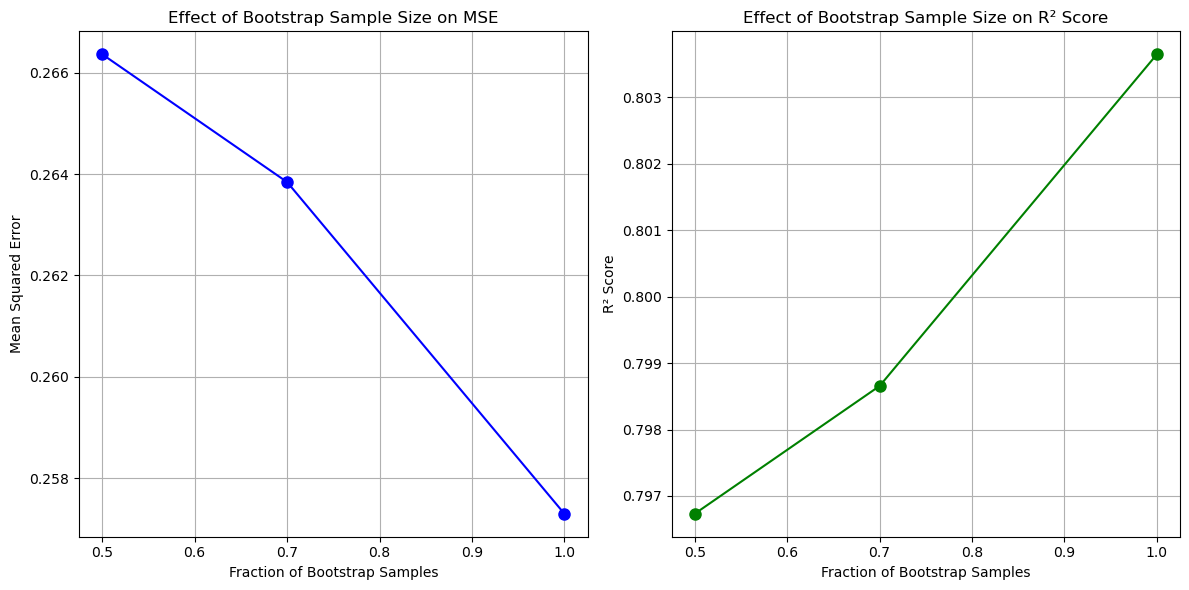

Max Samples: 0.5, MSE: 0.2664, R²: 0.7967
Max Samples: 0.7, MSE: 0.2638, R²: 0.7987
Max Samples: 1.0, MSE: 0.2573, R²: 0.8036


In [43]:
# 1. Load the dataset (California Housing dataset in this example)
data = fetch_california_housing()
X = data.data
y = data.target

# 2. Split the dataset into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize variables to store results
max_samples_list = [0.5, 0.7, 1.0]  # Different bootstrap sample fractions
mse_values = []
r2_values = []

# 4. Train Bagging Regressor with different max_samples values
for max_samples in max_samples_list:
    bagging_regressor = BaggingRegressor(
        base_estimator=DecisionTreeRegressor(),
        n_estimators=50,
        max_samples=max_samples,
        random_state=42
    )
    bagging_regressor.fit(X_train, y_train)
    
    # Make predictions and evaluate
    y_pred = bagging_regressor.predict(X_test)
    
    # Calculate MSE and R² score
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_values.append(mse)
    r2_values.append(r2)

# 5. Plot the comparison of performance
plt.figure(figsize=(12, 6))

# Plot MSE
plt.subplot(1, 2, 1)
plt.plot(max_samples_list, mse_values, marker='o', color='b', linestyle='-', markersize=8)
plt.title('Effect of Bootstrap Sample Size on MSE')
plt.xlabel('Fraction of Bootstrap Samples')
plt.ylabel('Mean Squared Error')
plt.grid(True)

# Plot R² Score
plt.subplot(1, 2, 2)
plt.plot(max_samples_list, r2_values, marker='o', color='g', linestyle='-', markersize=8)
plt.title('Effect of Bootstrap Sample Size on R² Score')
plt.xlabel('Fraction of Bootstrap Samples')
plt.ylabel('R² Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Print the results
for max_samples, mse, r2 in zip(max_samples_list, mse_values, r2_values):
    print(f"Max Samples: {max_samples}, MSE: {mse:.4f}, R²: {r2:.4f}")
